## Import Library

In [ ]:
import cv2
import mediapipe as mp
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Bidirectional, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import keras_tuner as kt
from keras.optimizers import Adam

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, classification_report

## Pre-Processing Data

### Feature Extraction (Mediapipe Pose Estimation)

In [9]:
# Setup MediaPipe
mp_pose = mp.solutions.pose
pose = mp_pose.Pose()

# Folder dataset
dataset_path = "../Dataset"
categories = ["Push-Up", "Lunges", "Sit-Up", "Pull-Up"]

# Inisialisasi penyimpanan data pose
pose_data = {"Push-Up": [], "Lunges": [], "Sit-Up": [], "Pull-Up": []}

os.makedirs('landmarks', exist_ok=True)

# Loop melalui kategori
for category in categories:
    category_path = os.path.join(dataset_path, category)
    
    if not os.path.exists(category_path):
        print(f"Folder {category} tidak ditemukan, melewati...")
        continue
    
    for video_file in os.listdir(category_path):
        if not video_file.endswith(".mp4"):  # Pastikan hanya membaca file video
            continue
        
        video_path = os.path.join(category_path, video_file)
        cap = cv2.VideoCapture(video_path)
        
        if not cap.isOpened():
            print(f"Gagal membuka {video_file}, melewati...")
            continue
        
        frame_id = 0
        while cap.isOpened():
            ret, frame = cap.read()
            if not ret:
                break
            
            frame_id += 1
            frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            results = pose.process(frame_rgb)
            
            if results.pose_landmarks:
                row = [frame_id]
                for lm in results.pose_landmarks.landmark:
                    row.extend([lm.x, lm.y, lm.z, lm.visibility])
                pose_data[category].append(row)
        
        cap.release()

# Simpan hasil ke CSV
for category in categories:
    if not pose_data[category]:  # Pastikan ada data sebelum menyimpan
        print(f"Tidak ada data pose untuk {category}.")
        continue
    
    columns = ["frame_id"] + [f"{i}_{axis}" for i in range(33) for axis in ["x", "y", "z", "visibility"]]
    df = pd.DataFrame(pose_data[category], columns=columns)
    output_path = f"landmarks/{category}_pose_data.csv"
    df.to_csv(output_path, index=False)
    
    print(f"Pose estimation untuk {category} selesai. Data disimpan di {output_path}")

Pose estimation untuk Push-Up selesai. Data disimpan di landmarks/Push-Up_pose_data.csv
Pose estimation untuk Lunges selesai. Data disimpan di landmarks/Lunges_pose_data.csv
Pose estimation untuk Sit-Up selesai. Data disimpan di landmarks/Sit-Up_pose_data.csv
Pose estimation untuk Pull-Up selesai. Data disimpan di landmarks/Pull-Up_pose_data.csv


### Display Data Count

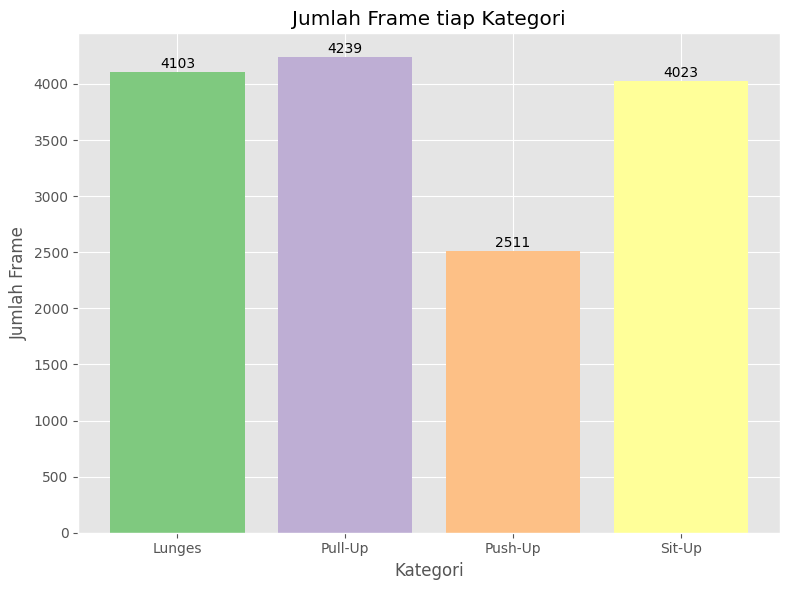

In [10]:
# Load data
data_pushup = pd.read_csv('./landmarks/Push-Up_pose_data.csv')
data_lunges = pd.read_csv('./landmarks/Lunges_pose_data.csv')
data_situp = pd.read_csv('./landmarks/Sit-Up_pose_data.csv')
data_pullup = pd.read_csv('./landmarks/Pull-Up_pose_data.csv')

# Hitung jumlah frame per kategori
counts = {
    'Lunges': len(data_lunges),
    'Pull-Up': len(data_pullup),
    'Push-Up': len(data_pushup),
    'Sit-Up': len(data_situp),
}

# Siapkan warna
cmap = plt.get_cmap('Accent')
colors = cmap(range(len(counts)))

# Gambar batang
plt.style.use('ggplot')
plt.figure(figsize=(8, 6))
bars = plt.bar(counts.keys(), counts.values(), color=colors)

# Tambahkan jumlah di atas tiap batang
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 10,
        str(height),
        ha='center',
        va='bottom',
        fontsize=10
    )

# Label dan judul
plt.title('Jumlah Frame tiap Kategori')
plt.xlabel('Kategori')
plt.ylabel('Jumlah Frame')
plt.tight_layout()
plt.show()

### Angle Calculation

In [20]:
# Indeks landmark yang dibutuhkan (12 sudut tubuh)
JOINTS = {
    # LEFT BODY
    "left_shoulder": [13, 11, 23],      # elbow - shoulder - hip
    "left_elbow": [11, 13, 15],         # shoulder - elbow - wrist
    "left_wrist": [13, 15, 19],         # elbow - wrist - index
    "left_hip": [11, 23, 25],           # shoulder - hip - knee
    "left_knee": [23, 25, 27],          # hip - knee - ankle
    "left_ankle": [25, 27, 31],         # knee - ankle - foot_index

    # RIGHT BODY
    "right_shoulder": [14, 12, 24],     # elbow - shoulder - hip
    "right_elbow": [12, 14, 16],        # shoulder - elbow - wrist
    "right_wrist": [14, 16, 20],        # elbow - wrist - index
    "right_hip": [12, 24, 26],          # shoulder - hip - knee
    "right_knee": [24, 26, 28],         # hip - knee - ankle
    "right_ankle": [26, 28, 32],        # knee - ankle - foot_index
}

data_dict = {
    "Push-Up": data_pushup,
    "Lunges": data_lunges,
    "Sit-Up": data_situp,
    "Pull-Up": data_pullup
}

os.makedirs('angle', exist_ok=True)

# Fungsi untuk menghitung sudut antara tiga titik dalam 2D
def calculate_angle_3d(a, b, c):
    """Menghitung sudut antara vektor AB dan BC dalam 2D"""
    ab = np.array([a[0] - b[0], a[1] - b[1]], a[2] - b[2])
    bc = np.array([c[0] - b[0], c[1] - b[1]], c[2] - b[2])
    
    dot_product = np.dot(ab, bc)
    magnitude_ab = np.linalg.norm(ab)
    magnitude_bc = np.linalg.norm(bc)

    if magnitude_ab == 0 or magnitude_bc == 0:
        return None

    cos_theta = dot_product / (magnitude_ab * magnitude_bc)
    cos_theta = np.clip(cos_theta, -1.0, 1.0)
    return np.degrees(np.arccos(cos_theta))


for name, df in data_dict.items():
    angle_data = []
    previous_angles = {joint: None for joint in JOINTS}

    for _, row in df.iterrows():
        angles = {}

        for joint, (a, b, c) in JOINTS.items():
            a_coord = (row[f"{a}_x"], row[f"{a}_y"], row[f"{a}_z"])
            b_coord = (row[f"{b}_x"], row[f"{b}_y"], row[f"{b}_z"])
            c_coord = (row[f"{c}_x"], row[f"{c}_y"], row[f"{c}_z"])
            
            angle = calculate_angle_3d(a_coord, b_coord, c_coord)

            if angle is None:
                opposite_joint = joint.replace("right", "left") if "right" in joint else joint.replace("left", "right")
                angle = previous_angles.get(opposite_joint)
            if angle is None:
                angle = previous_angles[joint]

            previous_angles[joint] = angle
            angles[joint] = angle

        angle_data.append(angles)

    angle_df = pd.DataFrame(angle_data)
    output_path = f"angle/{name}_angles.csv"
    angle_df.to_csv(output_path, index=False)
    print(f"Sudut untuk {name} selesai dihitung. Data disimpan di {output_path}")

Sudut untuk Push-Up selesai dihitung. Data disimpan di angle/Push-Up_angles.csv
Sudut untuk Lunges selesai dihitung. Data disimpan di angle/Lunges_angles.csv
Sudut untuk Sit-Up selesai dihitung. Data disimpan di angle/Sit-Up_angles.csv
Sudut untuk Pull-Up selesai dihitung. Data disimpan di angle/Pull-Up_angles.csv


## Train Model

### Load and Labeling Data

In [21]:
# Parameters
frame_per_sample = 30
stride = 10

# Sliding window implementation
def sliding_window(df, label, frame_per_sample, stride):
    features = df.values
    X, y = [], []

    for i in range(0, len(df) - frame_per_sample + 1, stride):
        window = features[i:i + frame_per_sample]
        X.append(window)
        y.append(label)

    return X, y

# Load all data
def load_data():
    files_labels = [
        ("./angle/Push-Up_angles.csv", "push-up"),
        ("./angle/Lunges_angles.csv", "lunges"),
        ("./angle/Sit-Up_angles.csv", "sit-up"),
        ("./angle/Pull-Up_angles.csv", "pull-up")
    ]

    all_X, all_y = [], []
    le = LabelEncoder()
    labels_encoded = le.fit_transform([label for _, label in files_labels])
    label_map = dict(zip([label for _, label in files_labels], labels_encoded))

    for file, label in files_labels:
        df = pd.read_csv(file).drop(columns=["label"], errors="ignore")
        X_part, y_part = sliding_window(df, label_map[label], frame_per_sample, stride)
        all_X.extend(X_part)
        all_y.extend(y_part)

    return np.array(all_X), np.array(all_y), le

# Load and split data
X, y, le = load_data()

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Label classes:", le.classes_)

X shape: (1478, 30, 12)
y shape: (1478,)
Label classes: ['lunges' 'pull-up' 'push-up' 'sit-up']


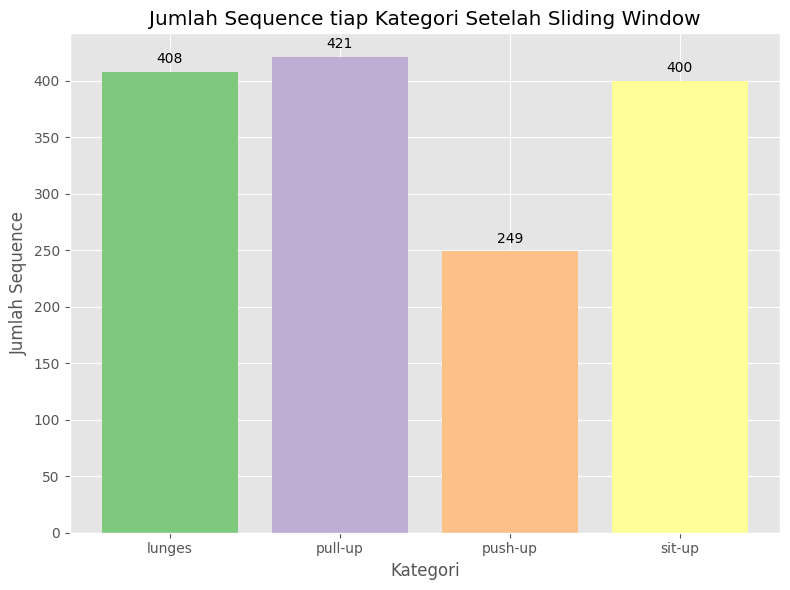

{'lunges': 408, 'pull-up': 421, 'push-up': 249, 'sit-up': 400}


In [22]:
unique, counts_raw = np.unique(y, return_counts=True)

label_names = [le.inverse_transform([u])[0] for u in unique]

counts = {label: count for label, count in zip(label_names, counts_raw)}

cmap = plt.get_cmap('Accent')
colors = cmap(range(len(counts)))

plt.style.use('ggplot')
plt.figure(figsize=(8, 6))
bars = plt.bar(counts.keys(), counts.values(), color=colors)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 5,
        str(height),
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.title('Jumlah Sequence tiap Kategori Setelah Sliding Window')
plt.xlabel('Kategori')
plt.ylabel('Jumlah Sequence')
plt.tight_layout()
plt.show()

print(counts)

### Split Data

In [23]:
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.1765, random_state=42, stratify=y_temp
)

# One-hot encoding
y_train = to_categorical(y_train, num_classes=4)
y_val   = to_categorical(y_val,   num_classes=4)
y_test  = to_categorical(y_test,  num_classes=4)

print("Train:", X_train.shape, y_train.shape)
print("Val:  ", X_val.shape,   y_val.shape)
print("Test: ", X_test.shape,  y_test.shape)

Train: (1034, 30, 12) (1034, 4)
Val:   (222, 30, 12) (222, 4)
Test:  (222, 30, 12) (222, 4)


### Hyperparameter Tuning (Random Search)

In [41]:
# Build model function
def build_model(hp):
    model = keras.Sequential([
        layers.Input(shape=(X_train.shape[1], X_train.shape[2])),

        layers.Bidirectional(
            layers.LSTM(
                units=hp.Choice("lstm_units_1", [32, 64, 128]),
                return_sequences=True
            )
        ),
        layers.Dropout(hp.Float("dropout_1", 0.1, 0.5, step=0.1)),

        layers.Bidirectional(
            layers.LSTM(units=hp.Choice("lstm_units_2", [32, 64, 128]))
        ),
        layers.Dropout(hp.Float("dropout_2", 0.1, 0.5, step=0.1)),

        layers.Dense(
            hp.Choice("dense_units", [32, 64, 128]),
            activation="relu"
        ),
        layers.Dropout(hp.Float("dropout_3", 0.1, 0.5, step=0.1)),

        layers.Dense(4, activation="softmax")
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(
            learning_rate=hp.Choice("learning_rate", [1e-2, 1e-3, 1e-4])
        ),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [ ]:
# Inisialisasi tuner
tuner = kt.RandomSearch(
    build_model,
    objective="val_accuracy",
    max_trials=25,
    executions_per_trial=1,
    directory="tuner_dir",
    project_name="pose_bilstm_tuning",
    overwrite=True
)

# Mulai tuning
tuner.search(
    X_train, y_train,
    epochs=30,
    validation_data=(X_val, y_val),
    callbacks=[EarlyStopping(monitor="val_loss", patience=5)],
    batch_size=32
)

# Ambil hyperparameter terbaik
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

# Tampilkan hyperparameter terbaik
print("Best hyperparameters:")
for p in best_hps.values:
    print(f"  {p}: {best_hps.get(p)}")

Trial 25 Complete [00h 00m 57s]
val_accuracy: 1.0

Best val_accuracy So Far: 1.0
Total elapsed time: 00h 14m 12s
Best hyperparameters:
  lstm_units_1: 128
  dropout_1: 0.4
  lstm_units_2: 64
  dropout_2: 0.2
  dense_units: 128
  dropout_3: 0.30000000000000004
  learning_rate: 0.001


### Training Model with The Best Hyperparameter

In [29]:
# Model Bi-LSTM menggunakan Hyperparameter terbaik
model = Sequential([
    Bidirectional(LSTM(128, return_sequences=True), input_shape=(X_train.shape[1], X_train.shape[2])),
    Dropout(0.4),
    Bidirectional(LSTM(128)),
    Dropout(0.2),
    Dense(128, activation="relu"),
    Dropout(0.30000000000000004),
    Dense(4, activation="softmax"),
])

# Compile model
model.compile(
    loss="categorical_crossentropy",
    optimizer=Adam(learning_rate=0.001),
    metrics=["accuracy"]
)

# Early stopping
early_stopping = EarlyStopping(
    monitor="val_loss", 
    patience=10, 
    restore_best_weights=True
)

# Train model
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=[early_stopping]
)

f:\Programming\X Pose Tracker\Machine Learning\mp-env\lib\site-packages\keras\src\layers\rnn\bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 12s 97ms/step - accuracy: 0.7740 - loss: 0.6165 - val_accuracy: 0.9910 - val_loss: 0.0152
Epoch 2/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 62ms/step - accuracy: 0.9851 - loss: 0.0454 - val_accuracy: 0.9865 - val_loss: 0.0231
Epoch 3/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 62ms/step - accuracy: 0.9901 - loss: 0.0240 - val_accuracy: 0.9955 - val_loss: 0.0054
Epoch 4/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 62ms/step - accuracy: 0.9987 - loss: 0.0060 - val_accuracy: 0.9955 - val_loss: 0.0042
Epoch 5/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 62ms/step - accuracy: 0.9964 - loss: 0.0110 - val_accuracy: 0.9910 - val_loss: 0.0408
Epoch 6/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 63ms/step - accuracy: 0.9957 - loss: 0.0098 - val_accuracy: 0.9955 - val_loss: 0.0128
Epoch 7/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 63ms/step - accuracy: 0.9984 - loss: 0.0050 - val_accuracy: 1.0000 - val_loss: 2.9490e-04
Epoch 8/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 63ms/step - accuracy: 0.9922 - loss: 0.0241 - val_accuracy: 1.000

### Display Learning Curves

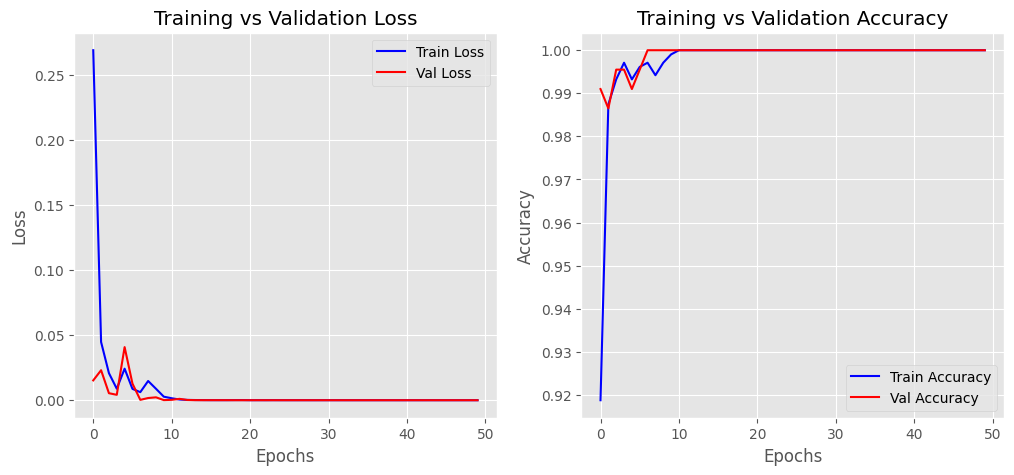

In [30]:
# Plot Loss & Accuracy selama training
plt.figure(figsize=(12, 5))

# Plot Loss
plt.subplot(1, 2, 1)
plt.plot(history.history["loss"], label="Train Loss", color="blue")
plt.plot(history.history["val_loss"], label="Val Loss", color="red")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

# Plot Accuracy
plt.subplot(1, 2, 2)
plt.plot(history.history["accuracy"], label="Train Accuracy", color="blue")
plt.plot(history.history["val_accuracy"], label="Val Accuracy", color="red")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()

plt.show()

### Model Evaluation (Confusion Matrix)

In [31]:
# Prediksi probabilitas
y_pred_probs = model.predict(X_test)

# Ambil kelas dengan probabilitas tertinggi
y_pred_classes = np.argmax(y_pred_probs, axis=1)

# Ambil label sebenarnya (karena masih one-hot)
y_true_classes = np.argmax(y_test, axis=1)

7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 173ms/step


In [ ]:
# Akurasi
accuracy = accuracy_score(y_true_classes, y_pred_classes)

# Presisi (macro agar tiap kelas dihitung rata-rata)
precision = precision_score(y_true_classes, y_pred_classes, average='macro')

# Recall (macro)
recall = recall_score(y_true_classes, y_pred_classes, average='macro')

# F1 Score (macro)
f1 = f1_score(y_true_classes, y_pred_classes, average='macro')

print("🔍 Hasil Evaluasi Model")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")

# Laporan lengkap per kelas
print("\n📄 Classification Report:")
print(classification_report(y_true_classes, y_pred_classes))

🔍 Hasil Evaluasi Model
Accuracy:  1.0000
Precision: 1.0000
Recall:    1.0000
F1 Score:  1.0000

📄 Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        61
           1       1.00      1.00      1.00        63
           2       1.00      1.00      1.00        38
           3       1.00      1.00      1.00        60

    accuracy                           1.00       222
   macro avg       1.00      1.00      1.00       222
weighted avg       1.00      1.00      1.00       222



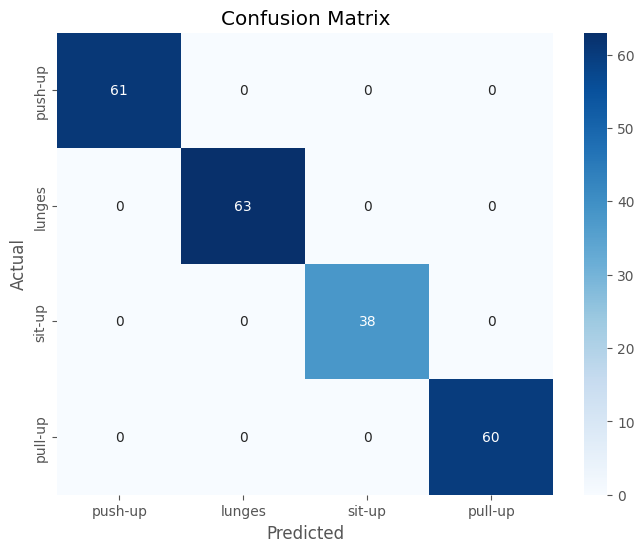

In [33]:
# Buat confusion matrix
cm = confusion_matrix(y_true_classes, y_pred_classes)
class_labels = ['push-up', 'lunges', 'sit-up', 'pull-up']

# Visualisasi confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

## Save Model (Tensorflow Lite)

In [52]:
# Konversi ke TFLite dengan dukungan Select TF Ops
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS,  # Ops standar TFLite
    tf.lite.OpsSet.SELECT_TF_OPS     # Tambahan ops dari TF (dibutuhkan untuk LSTM)
]
converter._experimental_lower_tensor_list_ops = False  # WAJIB untuk LSTM

# Konversi model
tflite_model = converter.convert()

# Simpan ke file .tflite
with open("bilstm_model.tflite", "wb") as f:
    f.write(tflite_model)

print("Model Bi-LSTM berhasil dikonversi ke TFLite dengan Select TF Ops.")

INFO:tensorflow:Assets written to: C:\Users\ASUS\AppData\Local\Temp\tmpxgrq699l\assets


INFO:tensorflow:Assets written to: C:\Users\ASUS\AppData\Local\Temp\tmpxgrq699l\assets


Saved artifact at 'C:\Users\ASUS\AppData\Local\Temp\tmpxgrq699l'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 30, 12), dtype=tf.float32, name='keras_tensor_8')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  2320747290768: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2318980867600: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2320747287424: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2320747285840: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2320747290592: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2320747287600: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2320747289184: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2320747295520: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2320747286368: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2320747291296: TensorSpec(shape=(), dtype=tf.resource, name=None)
  232074728